# GARCH Volatility Forecasting and VaR Backtesting: NIFTY Stocks

**Stocks:** TCS, Infosys, Asian Paints, Bajaj Finance

**What this notebook does**
1. Loads **split/bonus-adjusted** prices and flags suspicious one-day jumps that usually mean unadjusted corporate actions.
2. Fits GARCH(1,1) with Student-t errors on the full sample and reports persistence (α+β) and volatility half-life.
3. Produces **out-of-sample** 1-day-ahead volatility forecasts with a rolling window (no look-ahead).
4. Benchmarks GARCH against two standard alternatives: a **21-day historical volatility** and **EWMA (RiskMetrics, λ = 0.94)**.
5. Scores every model against **realised volatility** using MSE and QLIKE loss, and tests whether GARCH is significantly better with a **Diebold-Mariano test**.
6. Backtests **99% and 95% one-day VaR** with the **Kupiec** (unconditional coverage) and **Christoffersen** (independence) tests.
7. Summarises average volatility over the last 3, 6 and 9 months and forecasts volatility **14 trading days ahead**.

## 1. Configuration

In [3]:
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
!pip install arch
from arch import arch_model

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.figsize"] = (11, 5)

# ---- Data source ---------------------------------------------------------
# True  -> download adjusted prices from Yahoo Finance
# False -> read CSVs from DATA_FOLDER (uses 'Adj Close' if present, else 'Close')
USE_YFINANCE = True
DATA_FOLDER = "data"

TICKERS = {                      # display name -> Yahoo ticker / CSV file stem
    "TCS":          ("TCS.NS",        "tcs"),
    "Infosys":      ("INFY.NS",       "infosys"),
    "Asian Paints": ("ASIANPAINT.NS", "asianpaints"),
    "Bajaj Finance":("BAJFINANCE.NS", "bajaj"),
}
START, END = "2019-01-01", "2024-12-31"

# ---- Model settings ------------------------------------------------------
WINDOW = 500          # rolling estimation window in trading days (~2 years).
                      # 252 is usually too short for stable GARCH estimates.
REFIT_EVERY = 1       # refit parameters every N days (1 = daily, most rigorous;
                      # 5 runs ~5x faster; params are held fixed in between)
DIST = "t"            # error distribution: "t" (fat tails) or "normal"
EWMA_LAMBDA = 0.94    # RiskMetrics decay factor
HIST_WINDOW = 21      # historical-volatility benchmark window (1 month)
VAR_LEVELS = [0.99, 0.95]
HORIZON = 14          # forecast horizon in trading days
JUMP_THRESHOLD = 20   # flag |daily log return| above this many % as suspicious
TRADING_DAYS = 252

## 2. Load adjusted prices and check for corporate-action jumps

In [4]:
def load_prices():
    prices = {}
    if USE_YFINANCE:
        import yfinance as yf
        for name, (ticker, _) in TICKERS.items():
            df = yf.download(ticker, start=START, end=END, auto_adjust=True, progress=False)
            close = df["Close"]
            if isinstance(close, pd.DataFrame):
                close = close.iloc[:, 0]
            prices[name] = close.dropna()
    else:
        for name, (_, stem) in TICKERS.items():
            df = pd.read_csv(os.path.join(DATA_FOLDER, f"{stem}.csv"))
            df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
            df = df.set_index("Date").sort_index()
            col = "Adj Close" if "Adj Close" in df.columns else "Close"
            if col == "Close":
                print(f"WARNING [{name}]: no 'Adj Close' column; using raw Close. "
                      "Check the jump report below for unadjusted splits/bonuses.")
            prices[name] = pd.to_numeric(df[col], errors="coerce").dropna()
    return prices

prices = load_prices()

# Log returns in percent (scaling by 100 helps the optimiser converge)
returns = {n: (100 * np.log(p / p.shift(1))).replace([np.inf, -np.inf], np.nan).dropna()
           for n, p in prices.items()}

print(f"{'Stock':<15}{'Obs':>7}{'Start':>13}{'End':>13}{'Max |r| %':>11}")
for n, r in returns.items():
    print(f"{n:<15}{len(r):>7}{str(r.index[0].date()):>13}{str(r.index[-1].date()):>13}{r.abs().max():>11.2f}")

print("\nSuspicious one-day moves (possible unadjusted split/bonus):")
flagged = False
for n, r in returns.items():
    big = r[r.abs() > JUMP_THRESHOLD]
    for d, v in big.items():
        flagged = True
        print(f"  {n}: {d.date()}  {v:+.2f}%  (price ratio {np.exp(v/100):.3f})")
if not flagged:
    print("  None found. Prices look properly adjusted.")

Stock              Obs        Start          End  Max |r| %
TCS               1479   2019-01-02   2024-12-30       9.88
Infosys           1479   2019-01-02   2024-12-30      17.66
Asian Paints      1479   2019-01-02   2024-12-30      15.11
Bajaj Finance     1479   2019-01-02   2024-12-30      26.44

Suspicious one-day moves (possible unadjusted split/bonus):
  Bajaj Finance: 2020-03-23  -26.44%  (price ratio 0.768)


If a jump appears with a price ratio close to 0.5 (1:1 bonus), 0.2 (1:5 split) or 0.1 (1:10 split), the series is **not adjusted**. Switch to `USE_YFINANCE = True` or use an adjusted CSV before continuing, otherwise GARCH will treat the corporate action as an extreme volatility shock.

## 3. Full-sample GARCH(1,1) fit: parameters, persistence and half-life

In [5]:
full_results, param_rows = {}, []
for n, r in returns.items():
    res = arch_model(r, mean="Constant", vol="GARCH", p=1, q=1, dist=DIST).fit(disp="off")
    full_results[n] = res
    a, b = res.params["alpha[1]"], res.params["beta[1]"]
    persistence = a + b
    half_life = math.log(0.5) / math.log(persistence) if 0 < persistence < 1 else np.nan
    long_run_daily = math.sqrt(res.params["omega"] / (1 - persistence)) if persistence < 1 else np.nan
    param_rows.append({
        "Stock": n,
        "omega": res.params["omega"], "alpha": a, "beta": b,
        "p(alpha)": res.pvalues["alpha[1]"], "p(beta)": res.pvalues["beta[1]"],
        "alpha+beta": persistence,
        "Half-life (days)": half_life,
        "Long-run vol (ann. %)": long_run_daily * math.sqrt(TRADING_DAYS),
        "nu (t d.o.f.)": res.params.get("nu", np.nan),
        "Converged": res.convergence_flag == 0,
    })

params_df = pd.DataFrame(param_rows).set_index("Stock")
display(params_df)

,omega,alpha,beta,p(alpha),p(beta),alpha+beta,Half-life (days),Long-run vol (ann. %),nu (t d.o.f.),Converged
Stock,,,,,,,,,,
TCS,0.0849,0.0440,0.9185,0.0084,0.0000,0.9625,18.1348,23.8852,4.7581,True
Infosys,0.2738,0.0746,0.8280,0.0175,0.0000,0.9025,6.7603,26.6065,4.2331,True
Asian Paints,1.5009,0.3221,0.1840,0.0000,0.0724,0.5061,1.0179,27.6743,3.5964,True
Bajaj Finance,0.0843,0.0681,0.9253,0.0026,0.0000,0.9935,105.6622,56.9898,3.4105,True


**How to read this table**
- **alpha**: how strongly volatility reacts to yesterday's shock. **beta**: how much of yesterday's volatility carries over.
- **alpha + beta** close to 1 (typically 0.90 to 0.99 for large-cap equities) means volatility shocks die out slowly. The **half-life** is the number of days for a shock to lose half its effect.
- A **beta near zero with large p-values** means the model has not identified volatility clustering. Before trusting the model, check the data (Section 2) or the estimation window.
- **nu** below about 10 confirms fat tails, which is why Student-t errors are used instead of the normal distribution.

## 4. Out-of-sample 1-day-ahead forecasts: GARCH vs historical vol vs EWMA

In [6]:
def garch_rolling_forecast(r, window=WINDOW, refit_every=REFIT_EVERY, dist=DIST):
    # Forecast day i's variance and mean using only returns r[i-window : i]
    idx, var_f, mu_f, nu_f = [], [], [], []
    params = None
    for k, i in enumerate(range(window, len(r))):
        train = r.iloc[i - window:i]
        am = arch_model(train, mean="Constant", vol="GARCH", p=1, q=1, dist=dist)
        if params is None or k % refit_every == 0:
            res = am.fit(disp="off", starting_values=params)
            params = res.params
        else:
            res = am.fix(params)
        f = res.forecast(horizon=1, reindex=False)
        idx.append(r.index[i])
        var_f.append(f.variance.iloc[-1, 0])
        mu_f.append(params["mu"])
        nu_f.append(params.get("nu", np.nan))
    return pd.DataFrame({"var": var_f, "mu": mu_f, "nu": nu_f}, index=idx)

def ewma_forecast(r, lam=EWMA_LAMBDA, seed_window=WINDOW):
    # RiskMetrics: sigma2[t+1] = lam*sigma2[t] + (1-lam)*r[t]^2 (zero mean).
    # Value stored at date t is the forecast FOR date t, built from data up to t-1.
    sig2 = np.empty(len(r))
    sig2[0] = r.iloc[:seed_window].var()
    for t in range(1, len(r)):
        sig2[t] = lam * sig2[t - 1] + (1 - lam) * r.iloc[t - 1] ** 2
    return pd.Series(sig2, index=r.index)

def hist_forecast(r, window=HIST_WINDOW):
    return (r.rolling(window).std() ** 2).shift(1)   # uses data up to t-1 only

forecasts = {}
for n, r in returns.items():
    print(f"Rolling GARCH forecasts for {n} ...", end=" ")
    g = garch_rolling_forecast(r)
    df = pd.DataFrame(index=g.index)
    df["ret"] = r.loc[g.index]
    df["GARCH"] = g["var"]
    df["mu"] = g["mu"]
    df["nu"] = g["nu"]
    df["EWMA"] = ewma_forecast(r).loc[g.index]
    df["Hist21"] = hist_forecast(r).loc[g.index]
    forecasts[n] = df.dropna(subset=["GARCH", "EWMA", "Hist21"])
    print(f"{len(forecasts[n])} out-of-sample days")

Rolling GARCH forecasts for TCS ... 979 out-of-sample days
Rolling GARCH forecasts for Infosys ... 979 out-of-sample days
Rolling GARCH forecasts for Asian Paints ... 979 out-of-sample days
Rolling GARCH forecasts for Bajaj Finance ... 979 out-of-sample days


## 5. Forecast accuracy against realised volatility

The true daily variance is unobservable, so the standard proxy is the **next-day squared return**. Two loss functions are used:
- **MSE** of the variance forecast: intuitive, but sensitive to extreme days.
- **QLIKE** = r²/h − ln(r²/h) − 1: the loss preferred in the volatility literature (Patton, 2011) because it ranks models correctly even with a noisy proxy. It penalises *under*-forecasting risk more than over-forecasting, which is the right asymmetry for risk management.

The **Diebold-Mariano** test checks whether GARCH's lower loss is statistically significant rather than luck (negative statistic = GARCH better).

In [7]:
MODELS = ["GARCH", "EWMA", "Hist21"]

def losses(df, model):
    proxy = df["ret"] ** 2
    h = df[model]
    mse = (proxy - h) ** 2
    valid = proxy > 0                            # QLIKE undefined on exact zero-return days
    ratio = proxy[valid] / h[valid]
    qlike = ratio - np.log(ratio) - 1
    return mse, qlike

def diebold_mariano(l1, l2):
    # DM test with Newey-West HAC variance; negative stat => model 1 has lower loss
    d = (l1 - l2).dropna().values
    T = len(d)
    lag = int(np.floor(T ** (1 / 3)))
    d_c = d - d.mean()
    gamma0 = np.dot(d_c, d_c) / T
    lrv = gamma0 + 2 * sum((1 - k / (lag + 1)) * np.dot(d_c[k:], d_c[:-k]) / T
                           for k in range(1, lag + 1))
    stat = d.mean() / math.sqrt(lrv / T)
    return stat, 2 * (1 - stats.norm.cdf(abs(stat)))

acc_rows = []
for n, df in forecasts.items():
    L = {m: losses(df, m) for m in MODELS}
    row = {"Stock": n}
    for m in MODELS:
        row[f"MSE {m}"] = L[m][0].mean()
        row[f"QLIKE {m}"] = L[m][1].mean()
    for bench in ["EWMA", "Hist21"]:
        row[f"QLIKE gain vs {bench} %"] = 100 * (1 - row["QLIKE GARCH"] / row[f"QLIKE {bench}"])
        stat, p = diebold_mariano(L["GARCH"][1], L[bench][1])
        row[f"DM stat vs {bench}"], row[f"DM p vs {bench}"] = stat, p
    acc_rows.append(row)

accuracy_df = pd.DataFrame(acc_rows).set_index("Stock")
display(accuracy_df[[c for c in accuracy_df.columns if c.startswith("QLIKE")]])
display(accuracy_df[[c for c in accuracy_df.columns if c.startswith("DM")]])
display(accuracy_df[[c for c in accuracy_df.columns if c.startswith("MSE")]])

,QLIKE GARCH,QLIKE EWMA,QLIKE Hist21,QLIKE gain vs EWMA %,QLIKE gain vs Hist21 %
Stock,,,,,
TCS,1.6117,1.6479,1.7044,2.1985,5.4414
Infosys,1.5677,1.5772,1.5976,0.6049,1.8738
Asian Paints,1.7905,1.8054,1.9074,0.8285,6.1302
Bajaj Finance,1.8144,1.8392,1.9346,1.3447,6.2109


,DM stat vs EWMA,DM p vs EWMA,DM stat vs Hist21,DM p vs Hist21
Stock,,,,
TCS,-1.9558,0.0505,-2.8744,0.0040
Infosys,-0.4262,0.6699,-0.9975,0.3185
Asian Paints,-0.4030,0.6870,-2.0741,0.0381
Bajaj Finance,-0.6518,0.5145,-2.4615,0.0138


,MSE GARCH,MSE EWMA,MSE Hist21
Stock,,,
TCS,13.5174,13.5969,13.7989
Infosys,31.9721,32.2032,32.7457
Asian Paints,31.4400,29.8019,30.5939
Bajaj Finance,63.3226,62.2919,63.9550


### Forecast vs realised volatility (annualised)

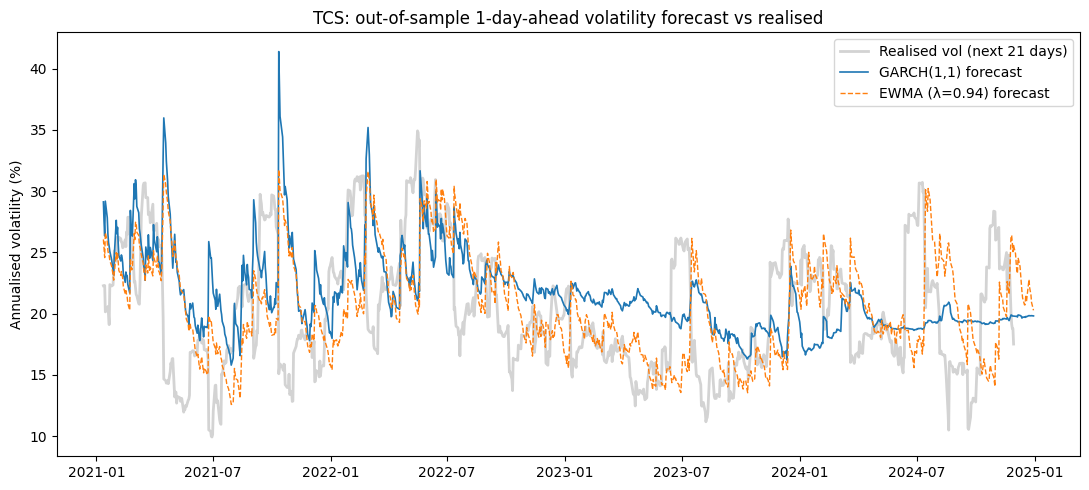

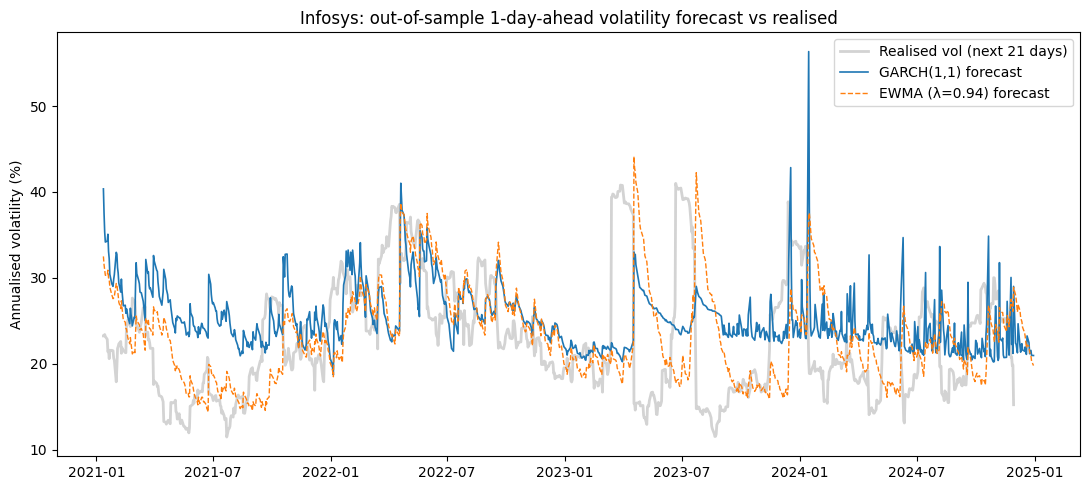

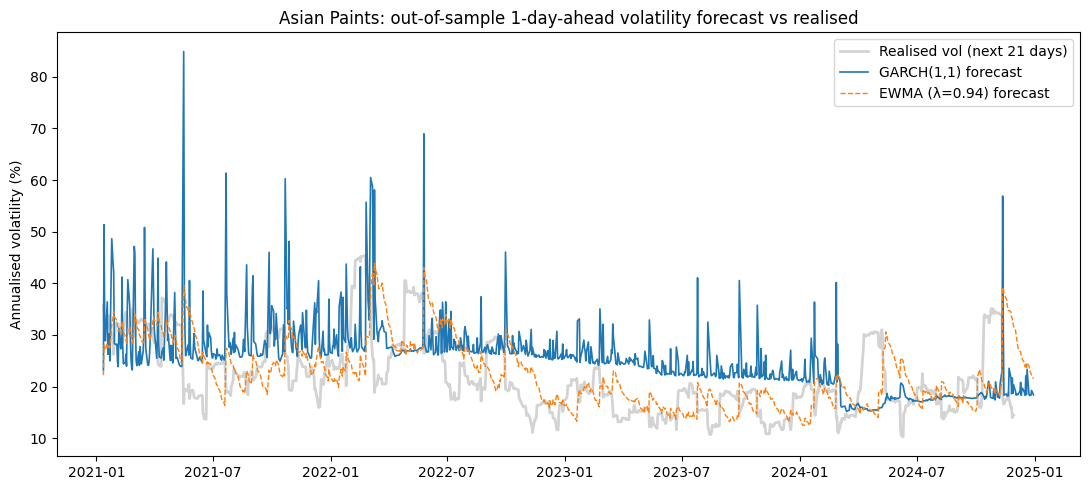

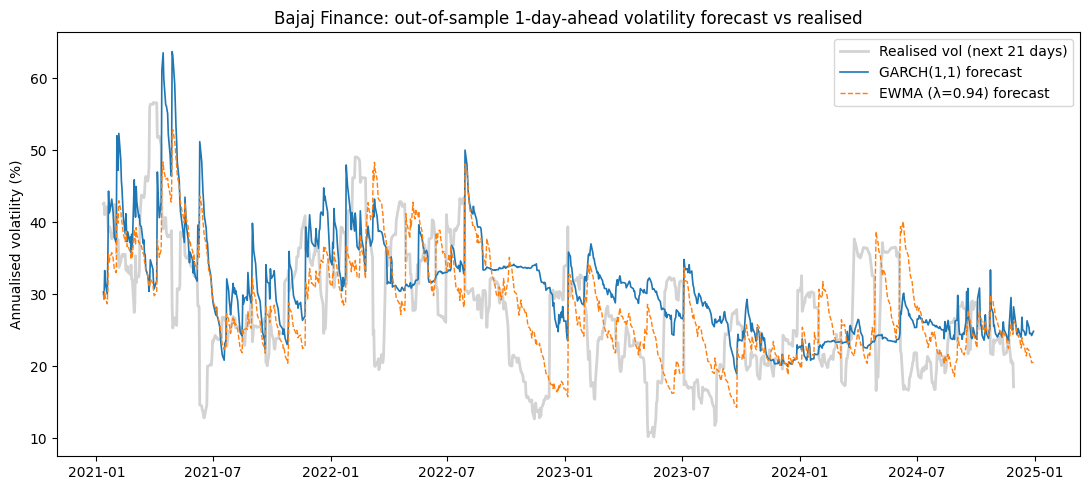

In [8]:
for n, df in forecasts.items():
    realised = returns[n].rolling(HIST_WINDOW).std().shift(-(HIST_WINDOW - 1))  # next-21-day realised vol
    ann = math.sqrt(TRADING_DAYS)
    fig, ax = plt.subplots()
    ax.plot(realised.loc[df.index] * ann, color="lightgray", lw=2, label="Realised vol (next 21 days)")
    ax.plot(np.sqrt(df["GARCH"]) * ann, lw=1.2, label="GARCH(1,1) forecast")
    ax.plot(np.sqrt(df["EWMA"]) * ann, lw=1, ls="--", label="EWMA (λ=0.94) forecast")
    ax.set_title(f"{n}: out-of-sample 1-day-ahead volatility forecast vs realised")
    ax.set_ylabel("Annualised volatility (%)")
    ax.legend(); plt.tight_layout(); plt.show()

## 6. Value-at-Risk backtest (99% and 95%, one day)

VaR is the loss threshold that should be breached on only (1 − level) of days. A good model should:
- breach at close to the expected rate (**Kupiec POF test**, p > 0.05 = pass), and
- not cluster its breaches together (**Christoffersen independence test**, p > 0.05 = pass).

GARCH VaR uses the forecast mean, forecast volatility and the fitted Student-t quantile. EWMA VaR uses the normal quantile, as in RiskMetrics.

In [9]:
def std_t_ppf(q, nu):
    # Quantile of a Student-t rescaled to unit variance (as used by arch)
    return stats.t.ppf(q, nu) * math.sqrt((nu - 2) / nu)

def kupiec(breaches, p):
    T, x = len(breaches), int(breaches.sum())
    pi = x / T
    ll0 = (T - x) * math.log(1 - p) + x * math.log(p)
    ll1 = ((T - x) * math.log(1 - pi) if pi < 1 else 0) + (x * math.log(pi) if x > 0 else 0)
    lr = -2 * (ll0 - ll1)
    return lr, 1 - stats.chi2.cdf(lr, 1)

def christoffersen(breaches):
    b = breaches.astype(int).values
    n00 = n01 = n10 = n11 = 0
    for prev, cur in zip(b[:-1], b[1:]):
        if prev == 0 and cur == 0: n00 += 1
        elif prev == 0 and cur == 1: n01 += 1
        elif prev == 1 and cur == 0: n10 += 1
        else: n11 += 1
    def ll(p, zeros, ones):
        out = 0.0
        if zeros: out += zeros * math.log(1 - p) if p < 1 else -np.inf
        if ones:  out += ones * math.log(p) if p > 0 else -np.inf
        return out
    pi0 = n01 / (n00 + n01) if (n00 + n01) else 0
    pi1 = n11 / (n10 + n11) if (n10 + n11) else 0
    pi = (n01 + n11) / (n00 + n01 + n10 + n11)
    lr = -2 * (ll(pi, n00 + n10, n01 + n11) - (ll(pi0, n00, n01) + ll(pi1, n10, n11)))
    return lr, 1 - stats.chi2.cdf(lr, 1)

var_rows, var_series = [], {}
for n, df in forecasts.items():
    for level in VAR_LEVELS:
        q = 1 - level
        if DIST == "t":
            z = df["nu"].apply(lambda v: std_t_ppf(q, v))
        else:
            z = stats.norm.ppf(q)
        var_garch = -(df["mu"] + np.sqrt(df["GARCH"]) * z)           # positive number = loss in %
        var_ewma = -(stats.norm.ppf(q) * np.sqrt(df["EWMA"]))
        var_series[(n, level)] = (var_garch, var_ewma)
        for model, v in [("GARCH-t" if DIST == "t" else "GARCH", var_garch), ("EWMA-normal", var_ewma)]:
            breaches = df["ret"] < -v
            lr_k, p_k = kupiec(breaches, q)
            lr_c, p_c = christoffersen(breaches)
            var_rows.append({
                "Stock": n, "Level": f"{int(level*100)}%", "Model": model,
                "Days": len(breaches), "Expected breaches": q * len(breaches),
                "Actual breaches": int(breaches.sum()),
                "Breach rate %": 100 * breaches.mean(),
                "Kupiec p": p_k, "Christoffersen p": p_c,
                "Pass (both p>0.05)": (p_k > 0.05) and (p_c > 0.05),
            })

var_df = pd.DataFrame(var_rows).set_index(["Stock", "Level", "Model"])
display(var_df)

Days  Expected breaches  Actual breaches  \
Stock         Level Model                                                   
TCS           99%   GARCH-t       979             9.7900               10   
                    EWMA-normal   979             9.7900               18   
              95%   GARCH-t       979            48.9500               50   
                    EWMA-normal   979            48.9500               49   
Infosys       99%   GARCH-t       979             9.7900               10   
                    EWMA-normal   979             9.7900               14   
              95%   GARCH-t       979            48.9500               46   
                    EWMA-normal   979            48.9500               49   
Asian Paints  99%   GARCH-t       979             9.7900               15   
                    EWMA-normal   979             9.7900               25   
              95%   GARCH-t       979            48.9500               50   
                    EWMA-normal   979            48.9500               51   
Bajaj Finance 99%   GARCH-t       979             9.7900               15   
                    EWMA-normal   979             9.7900               20   
              95%   GARCH-t       979            48.9500               50   
                    EWMA-normal   979            48.9500               48   

                                 Breach rate %  Kupiec p  Christoffersen p  \
Stock         Level Model                                                    
TCS           99%   GARCH-t             1.0215    0.9464            0.6494   
                    EWMA-normal         1.8386    0.0182            0.4113   
              95%   GARCH-t             5.1073    0.8780            0.7041   
                    EWMA-normal         5.0051    0.9942            0.2721   
Infosys       99%   GARCH-t             1.0215    0.9464            0.6494   
                    EWMA-normal         1.4300    0.2040            0.5237   
              95%   GARCH-t             4.6987    0.6622            0.0216   
                    EWMA-normal         5.0051    0.9942            0.3370   
Asian Paints  99%   GARCH-t             1.5322    0.1207            0.5091   
                    EWMA-normal         2.5536    0.0000            0.1454   
              95%   GARCH-t             5.1073    0.8780            0.0445   
                    EWMA-normal         5.2094    0.7652            0.0008   
Bajaj Finance 99%   GARCH-t             1.5322    0.1207            0.4942   
                    EWMA-normal         2.0429    0.0040            0.3608   
              95%   GARCH-t             5.1073    0.8780            0.7041   
                    EWMA-normal         4.9030    0.8889            0.8028   

                                 Pass (both p>0.05)  
Stock         Level Model                            
TCS           99%   GARCH-t                    True  
                    EWMA-normal               False  
              95%   GARCH-t                    True  
                    EWMA-normal                True  
Infosys       99%   GARCH-t                    True  
                    EWMA-normal                True  
              95%   GARCH-t                   False  
                    EWMA-normal                True  
Asian Paints  99%   GARCH-t                    True  
                    EWMA-normal               False  
              95%   GARCH-t                   False  
                    EWMA-normal               False  
Bajaj Finance 99%   GARCH-t                    True  
                    EWMA-normal               False  
              95%   GARCH-t                    True  
                    EWMA-normal                True

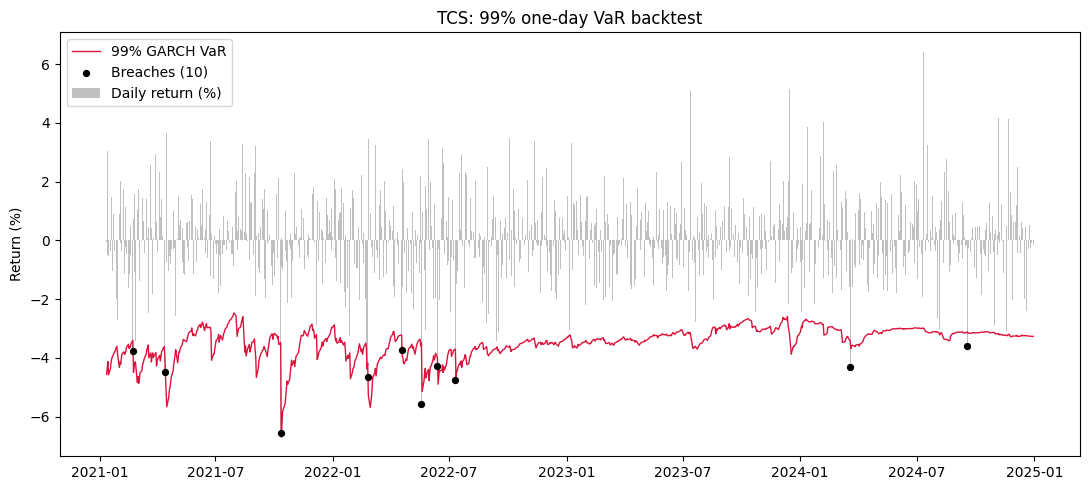

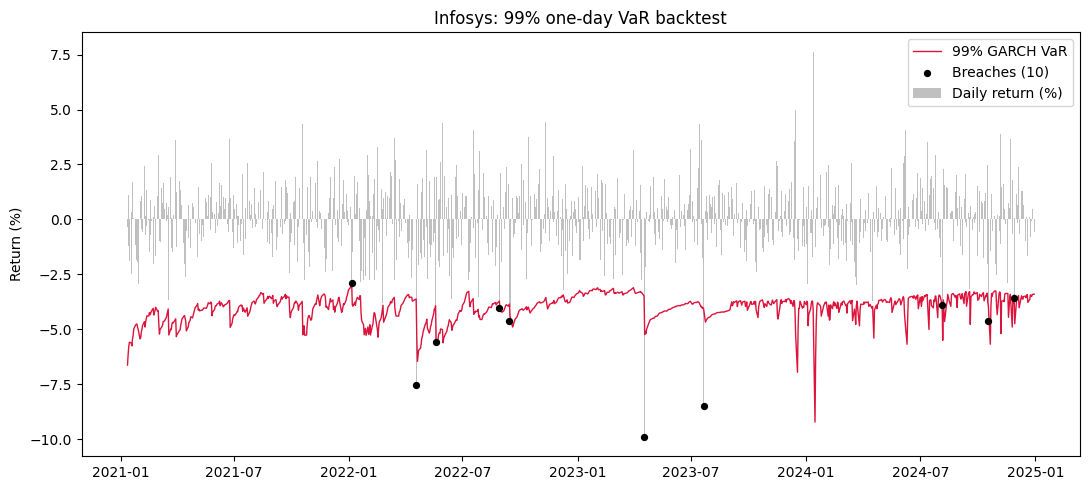

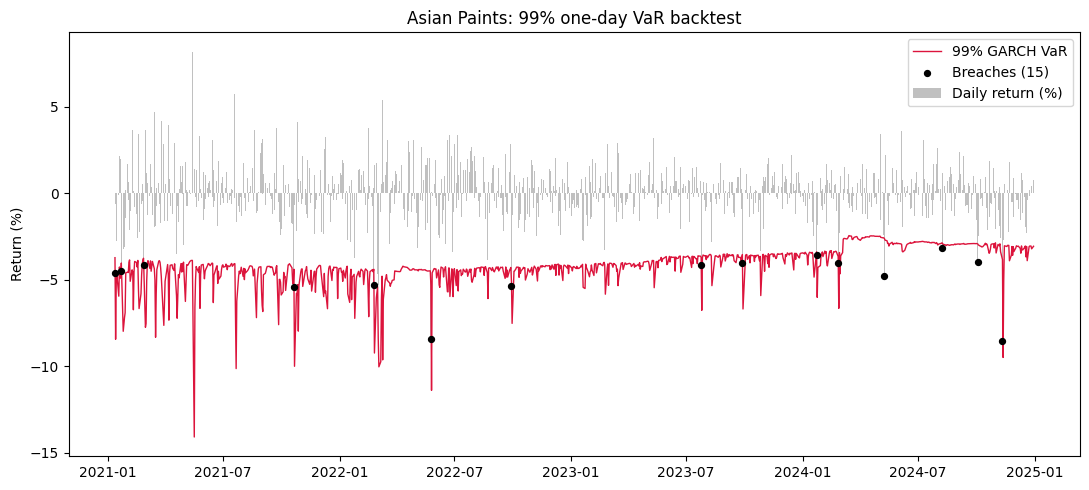

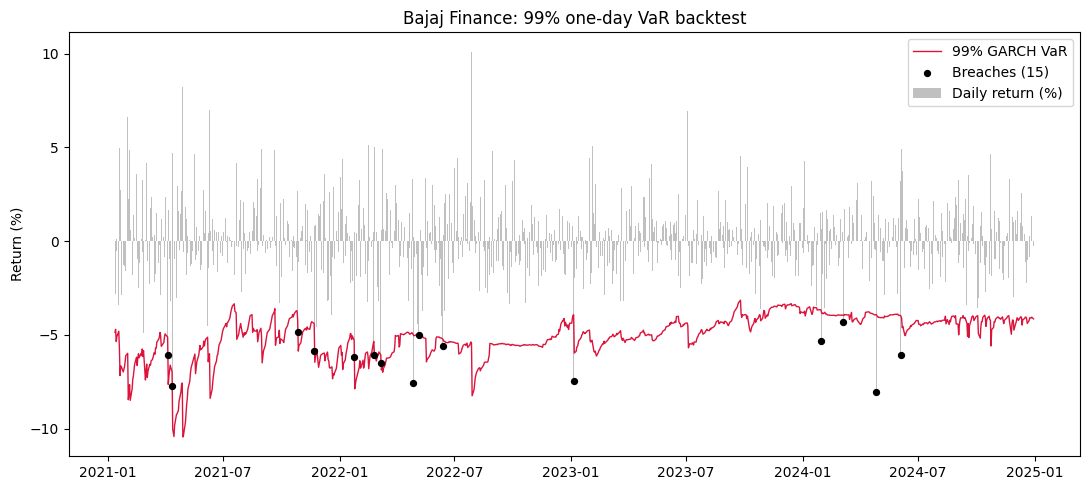

In [10]:
level = 0.99
for n, df in forecasts.items():
    v, _ = var_series[(n, level)]
    breaches = df["ret"] < -v
    fig, ax = plt.subplots()
    ax.bar(df.index, df["ret"], width=1.5, color="silver", label="Daily return (%)")
    ax.plot(-v, color="crimson", lw=1, label=f"{int(level*100)}% GARCH VaR")
    ax.scatter(df.index[breaches], df["ret"][breaches], color="black", s=18, zorder=3,
               label=f"Breaches ({int(breaches.sum())})")
    ax.set_title(f"{n}: {int(level*100)}% one-day VaR backtest")
    ax.set_ylabel("Return (%)"); ax.legend(); plt.tight_layout(); plt.show()

## 7. Average volatility over the last 3, 6 and 9 months

Volatility for each window is the average of the **full-sample** model's conditional volatility over that window, shown next to the realised volatility for the same window. Refitting GARCH on only ~63 days of data (as the original notebook did for 3 months) gives unreliable parameters, so it is avoided here.

In [11]:
period_rows = []
for n, r in returns.items():
    cv = full_results[n].conditional_volatility
    last = r.index.max()
    for label, months in [("3M", 3), ("6M", 6), ("9M", 9), ("Full", None)]:
        mask = r.index > (last - pd.DateOffset(months=months)) if months else slice(None)
        period_rows.append({
            "Stock": n, "Period": label,
            "Days": int(r[mask].shape[0]),
            "GARCH vol (ann. %)": cv[mask].mean() * math.sqrt(TRADING_DAYS),
            "Realised vol (ann. %)": r[mask].std() * math.sqrt(TRADING_DAYS),
        })
period_df = pd.DataFrame(period_rows).pivot(index="Stock", columns="Period",
                                             values=["GARCH vol (ann. %)", "Realised vol (ann. %)"])
period_df = period_df.reindex(columns=["3M", "6M", "9M", "Full"], level=1)
display(period_df)

GARCH vol (ann. %)                          \
Period                        3M      6M      9M    Full   
Stock                                                      
Asian Paints             26.0223 24.9253 24.9211 25.8760   
Bajaj Finance            29.0016 28.2730 29.8472 36.4458   
Infosys                  25.3698 24.8753 24.5695 26.3964   
TCS                      21.8790 22.3880 22.0352 23.5280   

              Realised vol (ann. %)                          
Period                           3M      6M      9M    Full  
Stock                                                        
Asian Paints                24.9611 22.1231 22.0962 25.6230  
Bajaj Finance               23.9590 23.1375 25.8337 37.6599  
Infosys                     23.9088 22.5717 21.6451 27.9893  
TCS                         20.7566 21.5943 20.2704 24.2079

## 8. Volatility forecast for the next 14 trading days

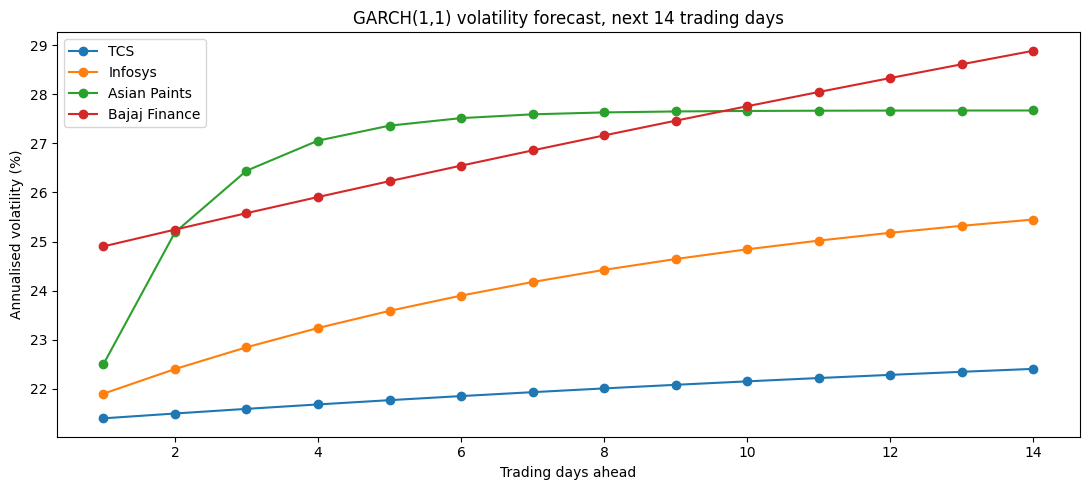

,Day 1 (ann. %),Day 14 (ann. %),Long-run (ann. %)
Stock,,,
TCS,21.3914,22.4010,23.8852
Infosys,21.8942,25.4487,26.6065
Asian Paints,22.4951,27.6736,27.6743
Bajaj Finance,24.9000,28.8933,56.9898


In [12]:
fig, ax = plt.subplots()
term_rows = []
for n, res in full_results.items():
    f = res.forecast(horizon=HORIZON, reindex=False)
    vol_path = np.sqrt(f.variance.iloc[-1].values) * math.sqrt(TRADING_DAYS)
    p = res.params["alpha[1]"] + res.params["beta[1]"]
    long_run = math.sqrt(res.params["omega"] / (1 - p) * TRADING_DAYS) if p < 1 else np.nan
    ax.plot(range(1, HORIZON + 1), vol_path, marker="o", label=n)
    term_rows.append({"Stock": n, "Day 1 (ann. %)": vol_path[0],
                      f"Day {HORIZON} (ann. %)": vol_path[-1],
                      "Long-run (ann. %)": long_run})
ax.set_xlabel("Trading days ahead"); ax.set_ylabel("Annualised volatility (%)")
ax.set_title(f"GARCH(1,1) volatility forecast, next {HORIZON} trading days")
ax.legend(); plt.tight_layout(); plt.show()
display(pd.DataFrame(term_rows).set_index("Stock"))

The forecast path drifts from today's volatility towards the long-run level at a speed set by alpha + beta. A path rising towards the long-run level means the market is currently calmer than normal; a falling path means it is currently more turbulent.

## 9. Results summary

In [13]:
gain_ewma = accuracy_df["QLIKE gain vs EWMA %"]
gain_hist = accuracy_df["QLIKE gain vs Hist21 %"]
sig_ewma = (accuracy_df["DM stat vs EWMA"] < 0) & (accuracy_df["DM p vs EWMA"] < 0.05)
v99 = var_df.xs(("99%", "GARCH-t" if DIST == "t" else "GARCH"), level=("Level", "Model"))
v99_ewma = var_df.xs(("99%", "EWMA-normal"), level=("Level", "Model"))

print("Forecast accuracy (QLIKE, lower is better)")
for n in accuracy_df.index:
    print(f"  {n:<14} GARCH vs EWMA: {gain_ewma[n]:+6.1f}%  (DM p = {accuracy_df.loc[n,'DM p vs EWMA']:.3f})"
          f"   GARCH vs 21-day hist: {gain_hist[n]:+6.1f}%")
print(f"\n  Average QLIKE improvement vs EWMA: {gain_ewma.mean():.1f}%")
print(f"  Average QLIKE improvement vs 21-day historical vol: {gain_hist.mean():.1f}%")
print(f"  GARCH significantly better than EWMA (5%) for {int(sig_ewma.sum())} of {len(sig_ewma)} stocks")

print("\n99% VaR backtest")
print(f"  GARCH-t passes Kupiec + Christoffersen for {int(v99['Pass (both p>0.05)'].sum())} of {len(v99)} stocks; "
      f"average breach rate {v99['Breach rate %'].mean():.2f}% (target 1.00%)")
print(f"  EWMA-normal passes for {int(v99_ewma['Pass (both p>0.05)'].sum())} of {len(v99_ewma)} stocks; "
      f"average breach rate {v99_ewma['Breach rate %'].mean():.2f}%")

print("\nPersistence (alpha+beta):", ", ".join(f"{n} {v:.3f}" for n, v in params_df["alpha+beta"].items()))

Forecast accuracy (QLIKE, lower is better)
  TCS            GARCH vs EWMA:   +2.2%  (DM p = 0.050)   GARCH vs 21-day hist:   +5.4%
  Infosys        GARCH vs EWMA:   +0.6%  (DM p = 0.670)   GARCH vs 21-day hist:   +1.9%
  Asian Paints   GARCH vs EWMA:   +0.8%  (DM p = 0.687)   GARCH vs 21-day hist:   +6.1%
  Bajaj Finance  GARCH vs EWMA:   +1.3%  (DM p = 0.515)   GARCH vs 21-day hist:   +6.2%

  Average QLIKE improvement vs EWMA: 1.2%
  Average QLIKE improvement vs 21-day historical vol: 4.9%
  GARCH significantly better than EWMA (5%) for 0 of 4 stocks

99% VaR backtest
  GARCH-t passes Kupiec + Christoffersen for 4 of 4 stocks; average breach rate 1.28% (target 1.00%)
  EWMA-normal passes for 1 of 4 stocks; average breach rate 1.97%

Persistence (alpha+beta): TCS 0.962, Infosys 0.903, Asian Paints 0.506, Bajaj Finance 0.993
